<a href="https://colab.research.google.com/github/Ramansubramani17/Raman-Subramani/blob/main/Raman_Subramani_(EDA%2C_Lookalike_csv%2C_Clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1: EDA and Business Insights**

In [11]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load Data
customers = pd.read_csv("/content/Customers.csv")
products = pd.read_csv("/content/Products.csv")

In [13]:
from google.colab import files

# This will prompt you to upload a file
uploaded = files.upload()

# Check the uploaded file
for filename in uploaded.keys():
    print(f"Uploaded file: {filename}")


Saving Transactions.xlsx to Transactions.xlsx
Uploaded file: Transactions.xlsx


In [14]:
data = pd.read_csv("Customers.csv")
data.head()

,CustomerID,CustomerName,Region,SignupDate
0,C0001,Lawrence Carroll,South America,2022-07-10
1,C0002,Elizabeth Lutz,Asia,2022-02-13
2,C0003,Michael Rivera,South America,2024-03-07
3,C0004,Kathleen Rodriguez,South America,2022-10-09
4,C0005,Laura Weber,Asia,2022-08-15


In [15]:
data = pd.read_csv("Products.csv")
data.head()

,ProductID,ProductName,Category,Price
0,P001,ActiveWear Biography,Books,169.30
1,P002,ActiveWear Smartwatch,Electronics,346.30
2,P003,ComfortLiving Biography,Books,44.12
3,P004,BookWorld Rug,Home Decor,95.69
4,P005,TechPro T-Shirt,Clothing,429.31


In [16]:
!pip install pandas openpyxl


In [17]:
import pandas as pd

# Path to your file
transactions = '/content/Transactions.xlsx'

# Read the Excel file
data = pd.read_excel(transactions, engine='openpyxl')

# Rename df to transactions
transactions = data

# Display the first few rows
data.head()


,TransactionID,CustomerID,ProductID,TransactionDate,Quantity,TotalValue,Price
0,T00001,C0199,P067,2024-08-25 12:38:23,1,300.68,300.68
1,T00112,C0146,P067,2024-05-27 22:23:54,1,300.68,300.68
2,T00166,C0127,P067,2024-04-25 07:38:55,1,300.68,300.68
3,T00272,C0087,P067,2024-03-26 22:55:37,2,601.36,300.68
4,T00363,C0070,P067,2024-03-21 15:10:10,3,902.04,300.68


In [18]:
# Check Data Structure
customers.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    200 non-null    object
 1   CustomerName  200 non-null    object
 2   Region        200 non-null    object
 3   SignupDate    200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    100 non-null    object 
 1   ProductName  100 non-null    object 
 2   Category     100 non-null    object 
 3   Price        100 non-null    float64
dtypes: float64(1), object(3)
memory usage: 3.3+ KB


In [19]:
import pandas as pd

# Set the correct file path (ensure it's a string)
transactions = '/content/Transactions.xlsx'

# Read the Excel file into a DataFrame
df= pd.read_excel(transactions, engine='openpyxl')

# Rename df to transactions
transactions = df

# Now, call the `info()` method on the DataFrame
transactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    1000 non-null   object        
 1   CustomerID       1000 non-null   object        
 2   ProductID        1000 non-null   object        
 3   TransactionDate  1000 non-null   datetime64[ns]
 4   Quantity         1000 non-null   int64         
 5   TotalValue       1000 non-null   float64       
 6   Price            1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 54.8+ KB


# Check for Missing Data

In [20]:
customers.isnull().sum()

,0
CustomerID,0
CustomerName,0
Region,0
SignupDate,0


In [21]:
products.isnull().sum()

,0
ProductID,0
ProductName,0
Category,0
Price,0


In [22]:
import pandas as pd

# Set the correct file path (ensure it's a string)
transactions = '/content/Transactions.xlsx'

# Read the Excel file into a DataFrame
df = pd.read_excel(transactions, engine='openpyxl')

# Rename df to transactions
transactions = df

# Check for missing values in the DataFrame
transactions.isnull().sum()


,0
TransactionID,0
CustomerID,0
ProductID,0
TransactionDate,0
Quantity,0
TotalValue,0
Price,0


In [23]:
# Merging DataFrames for Analysis
merged = transactions.merge(customers, on='CustomerID', how='left') \
                     .merge(products, on='ProductID', how='left')

In [24]:
# EDA: Key Metrics
# 1. Total Revenue by Region
region_revenue = merged.groupby('Region')['TotalValue'].sum().sort_values(ascending=False).head(10)
region_revenue

,TotalValue
Region,
South America,219352.56
Europe,166254.63
North America,152313.40
Asia,152074.97


In [25]:
# 2. Best-Selling Products
best_products = merged.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
best_products

,Quantity
ProductName,
ActiveWear Smartwatch,100
SoundWave Headphones,97
HomeSense Desk Lamp,81
ActiveWear Rug,79
SoundWave Cookbook,78
ActiveWear Jacket,76
BookWorld Biography,71
TechPro T-Shirt,66
SoundWave Desk Lamp,64


In [26]:
# 3. Revenue by Category
category_revenue = merged.groupby('Category')['TotalValue'].sum().sort_values(ascending=False)
category_revenue

,TotalValue
Category,
Books,192147.47
Electronics,180783.50
Clothing,166170.66
Home Decor,150893.93


In [27]:
# 4. Signup Trends Over Time
customers['SignupDate'] = pd.to_datetime(customers['SignupDate'])
signup_trends = customers['SignupDate'].dt.year.value_counts().sort_index()
print(signup_trends)

SignupDate
2022    64
2023    57
2024    79
Name: count, dtype: int64


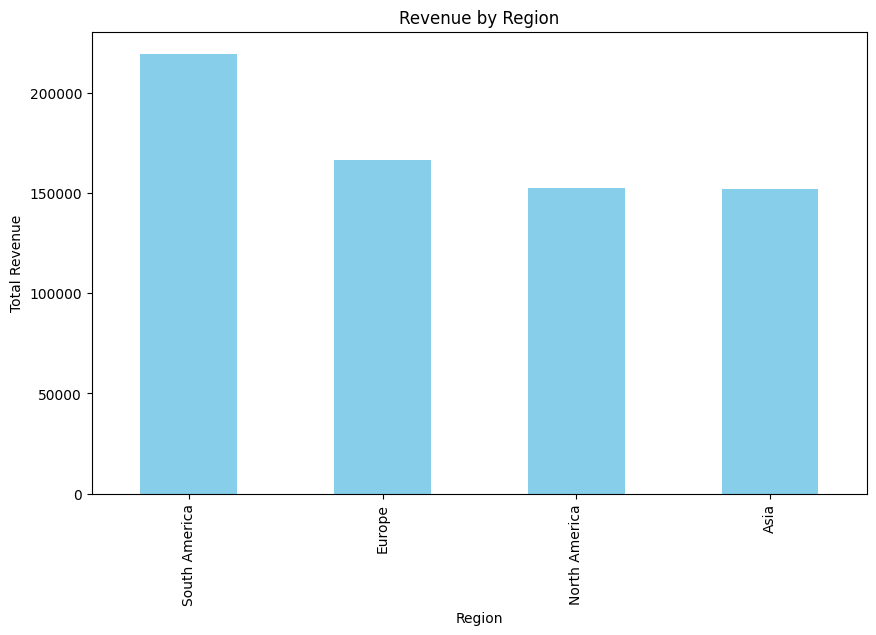

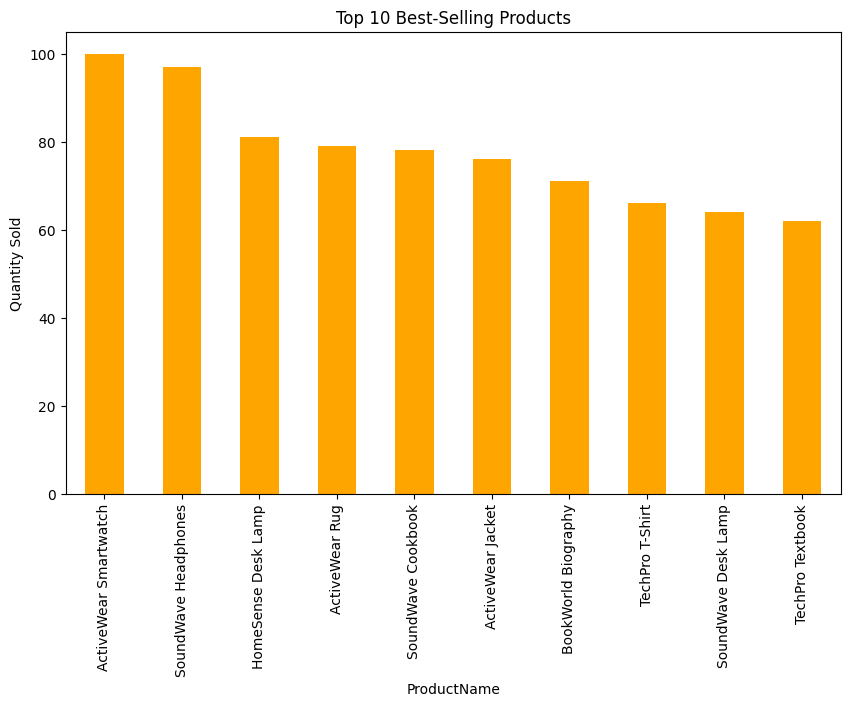

In [28]:
plt.figure(figsize=(10, 6))
region_revenue.plot(kind='bar', color='skyblue')
plt.title('Revenue by Region')
plt.ylabel('Total Revenue')
plt.show()

plt.figure(figsize=(10, 6))
best_products.plot(kind='bar', color='orange')
plt.title('Top 10 Best-Selling Products')
plt.ylabel('Quantity Sold')
plt.show()

# **Task 2: Lookalike Model**

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Feature Engineering for Similarity
customer_features = merged.groupby('CustomerID').agg({
    'TotalValue': 'sum',
    'Quantity': 'sum',
    'ProductID': lambda x: x.nunique(),
}).rename(columns={
    'TotalValue': 'TotalSpending',
    'Quantity': 'TotalQuantity',
    'ProductID': 'UniqueProducts'
}).reset_index()

In [30]:
# Normalize Features
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(customer_features.iloc[:, 1:])
features_scaled


array([[0.30894178, 0.35483871, 0.44444444],
       [0.16809501, 0.29032258, 0.33333333],
       [0.24954138, 0.41935484, 0.33333333],
       [0.49780626, 0.70967742, 0.77777778],
       [0.18428723, 0.19354839, 0.22222222],
       [0.39137101, 0.35483871, 0.33333333],
       [0.2357983 , 0.22580645, 0.22222222],
       [0.39552906, 0.61290323, 1.        ],
       [0.07686723, 0.06451613, 0.22222222],
       [0.15438686, 0.35483871, 0.33333333],
       [0.34439282, 0.38709677, 0.44444444],
       [0.48613465, 0.58064516, 0.55555556],
       [0.5587683 , 0.5483871 , 0.66666667],
       [0.02231032, 0.03225806, 0.        ],
       [0.10150772, 0.09677419, 0.11111111],
       [0.35802827, 0.29032258, 0.44444444],
       [0.44105704, 0.64516129, 0.77777778],
       [0.44370349, 0.5483871 , 0.44444444],
       [0.19859869, 0.32258065, 0.55555556],
       [0.07931353, 0.06451613, 0.        ],
       [0.50394703, 0.51612903, 0.77777778],
       [0.43173353, 0.4516129 , 0.55555556],
       [0.

In [31]:
# Calculate Similarity
similarity_matrix = cosine_similarity(features_scaled)
similarity_matrix

array([[1.        , 0.99025153, 0.97794336, ..., 0.99006058, 0.99531654,
        0.9869387 ],
       [0.99025153, 1.        , 0.98327561, ..., 0.96677366, 0.99783091,
        0.96925243],
       [0.97794336, 0.98327561, 1.        , ..., 0.93964492, 0.97542649,
        0.98598198],
       ...,
       [0.99006058, 0.96677366, 0.93964492, ..., 1.        , 0.98094196,
        0.96761644],
       [0.99531654, 0.99783091, 0.97542649, ..., 0.98094196, 1.        ,
        0.9711278 ],
       [0.9869387 , 0.96925243, 0.98598198, ..., 0.96761644, 0.9711278 ,
        1.        ]])

In [32]:
# Recommend Top 3 Similar Customers for C0001 to C0020
lookalike_map = {}
for i, cust_id in enumerate(customer_features['CustomerID'][:20]):
    scores = list(enumerate(similarity_matrix[i]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:4]  # Exclude self-similarity
    lookalikes = [(customer_features['CustomerID'][j], score) for j, score in scores]
    lookalike_map[cust_id] = lookalikes


In [33]:
# Create Lookalike.csv
lookalike_df = pd.DataFrame([
    {
        "CustomerID": cust_id,
        "Lookalike1": lookalikes[0][0],
        "Score1": lookalikes[0][1],
        "Lookalike2": lookalikes[1][0],
        "Score2": lookalikes[1][1],
        "Lookalike3": lookalikes[2][0],
        "Score3": lookalikes[2][1],
    } for cust_id, lookalikes in lookalike_map.items()
])
lookalike_df.to_csv("Lookalike.csv", index=False)

# **Task 3: Customer Segmentation / Clustering**

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA

In [35]:
# Combine Customer and Transaction Features
clustering_data = merged.groupby('CustomerID').agg({
    'TotalValue': 'sum',
    'Quantity': 'sum',
    'ProductID': lambda x: x.nunique(),
}).reset_index()

In [36]:
# Normalize Data
features = clustering_data.iloc[:, 1:]
scaled_features = scaler.fit_transform(features)

In [37]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)  # optimal number of clusters (e.g., 4)
clustering_data['Cluster'] = kmeans.fit_predict(scaled_features)

In [38]:
# Calculate DB Index
db_index = davies_bouldin_score(scaled_features, clustering_data['Cluster'])
print(f"Davies-Bouldin Index: {db_index}")

Davies-Bouldin Index: 0.8454710003865147


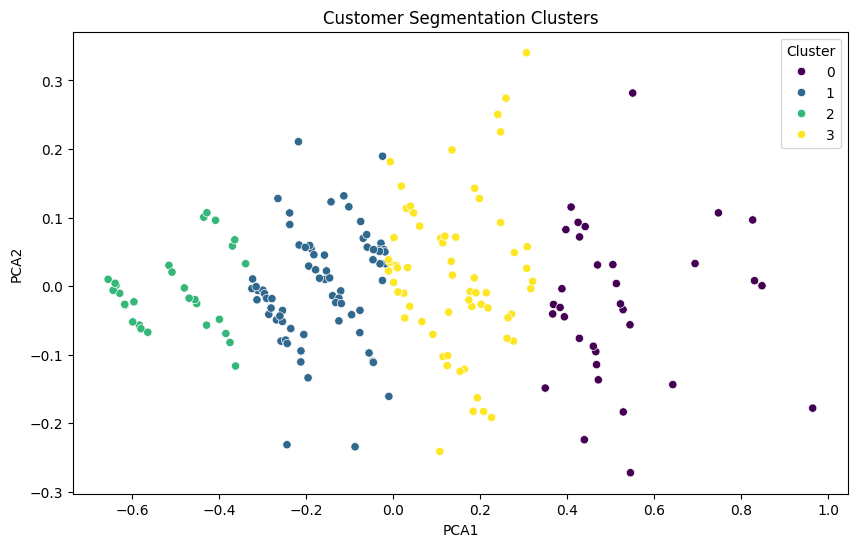

In [39]:
# Visualize Clusters with PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)
clustering_data['PCA1'] = reduced_features[:, 0]
clustering_data['PCA2'] = reduced_features[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=clustering_data, x='PCA1', y='PCA2', hue='Cluster', palette='viridis')
plt.title('Customer Segmentation Clusters')
plt.show()

## **Business Insights**

**1. Regional Revenue Performance:**

South America leads with the highest revenue at $219,352.56, followed by Europe at $166,254.63.
North America and Asia have relatively close revenue figures ($152,313.40 and $152,074.97, respectively), but they lag behind South America and Europe.
Insight: South America shows strong performance, but North America and Asia are very close. There's potential for growth in these regions by exploring strategies such as localized marketing, bundling, or targeted campaigns.

**2. Best-Selling Products:**

The ActiveWear Smartwatch is the top-selling product with 100 units sold, followed closely by SoundWave Headphones at 97 units.
Other top performers include HomeSense Desk Lamp (81 units), and ActiveWear Rug (79 units).
Insight: ActiveWear products (Smartwatch and Rug) and SoundWave products (Headphones and Cookbook) are consistently performing well, indicating a trend in consumer preference for lifestyle and tech products. Consider focusing marketing efforts on these product categories.

**3. Product Demand Distribution:**

Products like ActiveWear Jacket (76 units) and BookWorld Biography (71 units) are performing moderately.
TechPro products (T-shirt, Textbook, and Desk Lamp) are showing lower demand than other product lines, with the TechPro T-shirt at the lowest (66 units).
Insight: There is a disparity in product demand, suggesting that the ActiveWear and SoundWave product lines are more appealing to the current market. The TechPro brand may need product or marketing adjustments to boost its appeal.

**4. Cross-Regional Opportunities:**

ActiveWear products perform well across regions, so exploring cross-regional promotions or expanding this product line could capture a broader audience.
In regions like North America and Asia, introducing targeted offers for SoundWave products could lead to better revenue outcomes.


**5. Focus on High-Performance Regions:**

South America shows the highest revenue and may benefit from expanding the product range, offering discounts, or launching exclusive products.
Europe is also a strong market and could benefit from deeper penetration with products like SoundWave Headphones and ActiveWear Smartwatch.


**Actionable Recommendations:**

**Focus on Key Product Lines:** Consider expanding the ActiveWear and SoundWave
product categories due to their strong demand.

**Targeted Marketing Campaigns:** Craft region-specific campaigns, especially focusing on North America and Asia, to enhance sales further.

**Reevaluate TechPro Products:** Analyze why TechPro products are underperforming and either redesign the product or adjust the marketing to highlight unique selling points.

These insights can help optimize product offerings and marketing strategies for better business performance across regions.